In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost plotly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

In [3]:
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


In [4]:
trader = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print(trader.head())
print(sentiment.head())


                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [6]:
print(trader.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


**Data Cleaning**

In [7]:
# Convert trader date
trader['Date'] = pd.to_datetime(trader['Date']).dt.date

# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Rename column so both match
sentiment = sentiment.rename(columns={'date':'Date'})

**Merge Datasets**

In [8]:
data = pd.merge(trader, sentiment, on="Date", how="inner")

print(data.head())
print("Merged dataset shape:",data.shape)

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

**Feature Engineering*

In [9]:
# Convert sentiment to numeric
data["sentiment_label"] = data["classification"].map({
"Fear":0,
"Greed":1
})

# Profit flag
data["profit_flag"] = data["Closed PnL"].apply(lambda x:1 if x>0 else 0)

**Correlation Matrix**

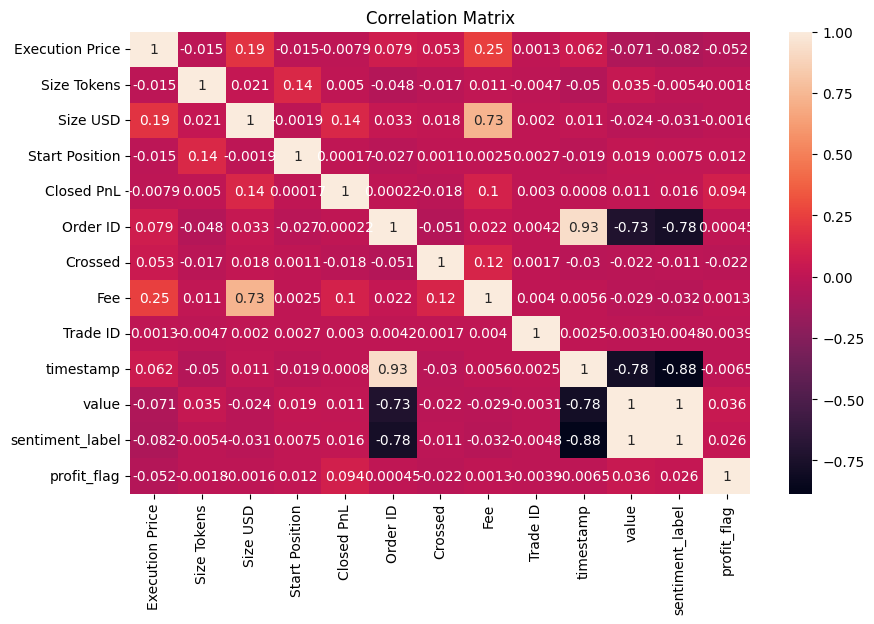

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True),annot=True)
plt.title("Correlation Matrix")
plt.show()

**explanations**
The correlation matrix shows the relationship between numerical variables in the dataset.
It helps identify which features have strong or weak influence on trader profit and trading behavior.

**Graph 1 — Sentiment vs Profit**

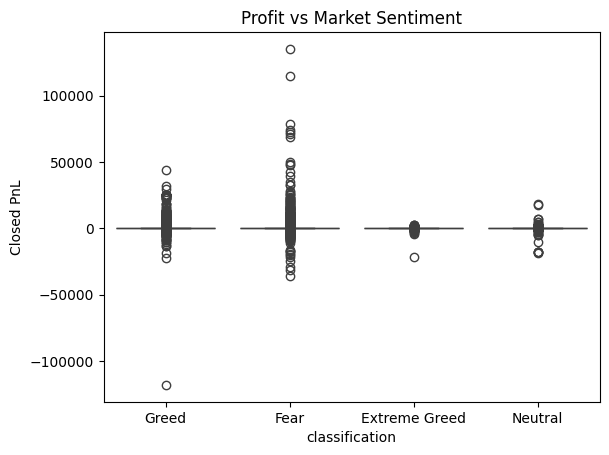

In [11]:
sns.boxplot(x="classification",y="Closed PnL",data=data)
plt.title("Profit vs Market Sentiment")
plt.show()

**Explanation**
This boxplot compares trader profits during Fear and Greed market conditions.
It helps identify whether traders perform better during fearful markets or greedy markets.

**Buy Sell Behaviour**

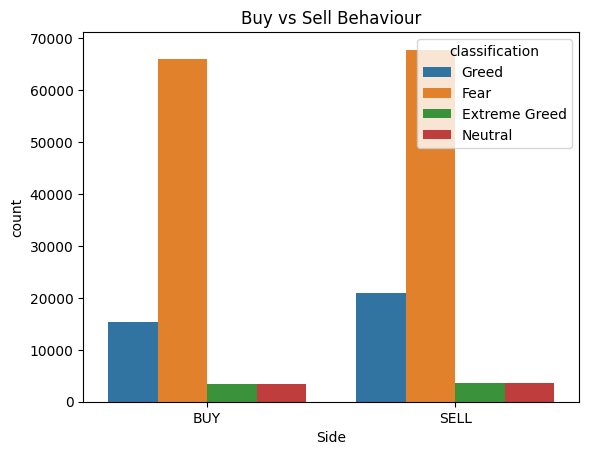

In [12]:
sns.countplot(x="Side",hue="classification",data=data)
plt.title("Buy vs Sell Behaviour")
plt.show()

**Explanation**
This chart shows how traders behave (buy or sell) under different market sentiments.
It helps understand whether traders tend to buy more in fearful markets or sell during greedy markets.


****

**Trade Size Distribution**

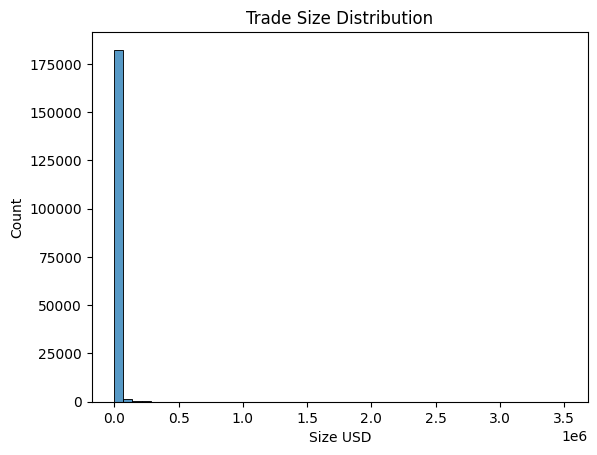

In [13]:
sns.histplot(data["Size USD"],bins=50)
plt.title("Trade Size Distribution")
plt.show()

**Explanation**
This histogram displays the distribution of trade sizes in USD.
It helps identify whether most traders prefer small trades or large trading positions.


**Graph 4 — Trade Size vs Profit**

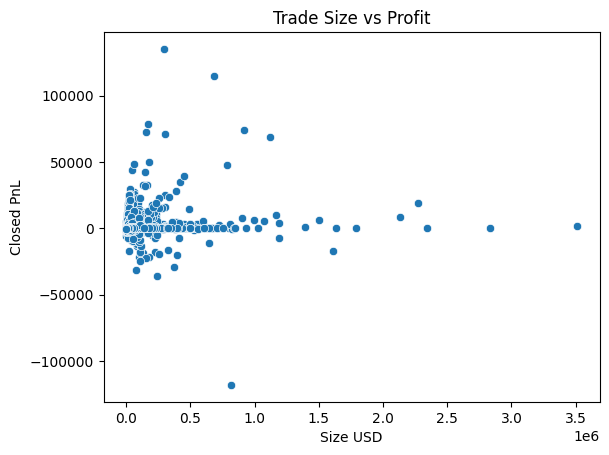

In [14]:
sns.scatterplot(x="Size USD",y="Closed PnL",data=data)
plt.title("Trade Size vs Profit")
plt.show()


**explanation**
This scatter plot shows the relationship between trade size and trader profit.
It helps determine whether larger trades lead to higher profits or higher risks.

**Leverage vs Profit**

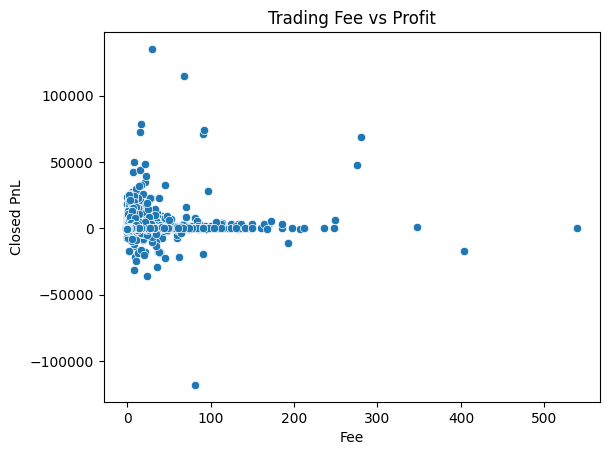

In [15]:
sns.scatterplot(x="Fee",y="Closed PnL",data=data)
plt.title("Trading Fee vs Profit")
plt.show()

**Explanation**
This graph shows the relationship between trading fees and profit or loss.
It helps analyze whether high trading costs affect overall trader profitability.

**Top Coins**

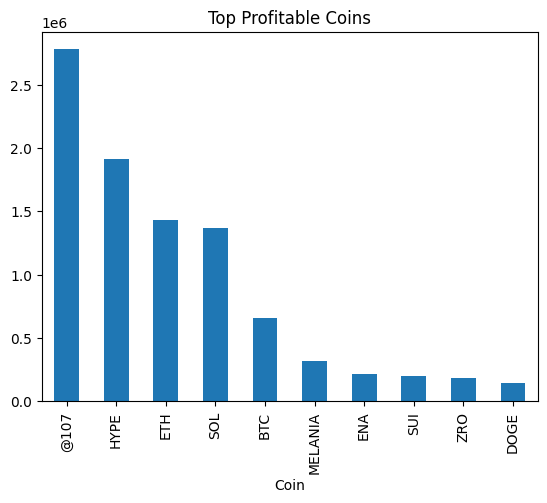

In [16]:
coin_profit = data.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10)

coin_profit.plot(kind="bar")
plt.title("Top Profitable Coins")
plt.show()

**Explanations**
This bar chart shows the coins that generated the highest total profits for traders.
It helps identify which cryptocurrencies are most profitable in the trading dataset.


**Top Traders**

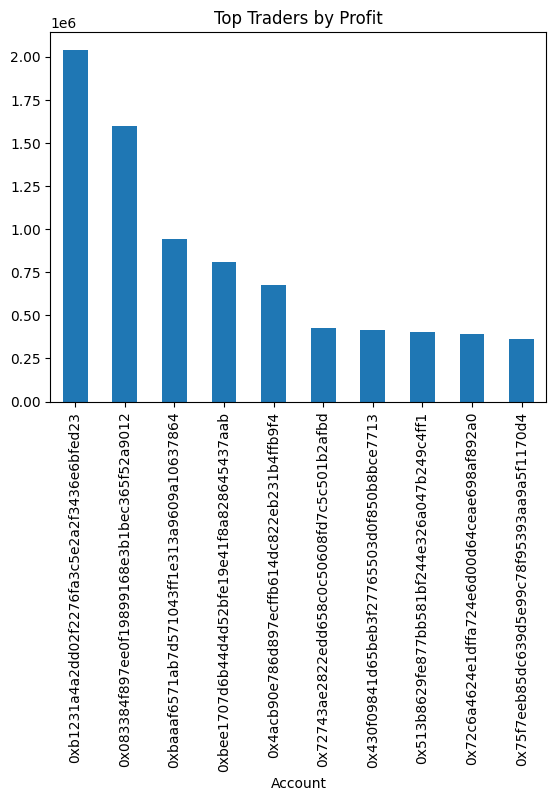

In [17]:
top_traders = data.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

top_traders.plot(kind="bar")
plt.title("Top Traders by Profit")
plt.show()

**Explanations**
This chart displays the traders who generated the highest overall profits.
It helps identify the most successful traders and analyze their trading performance.


**Daily Profit Trend**

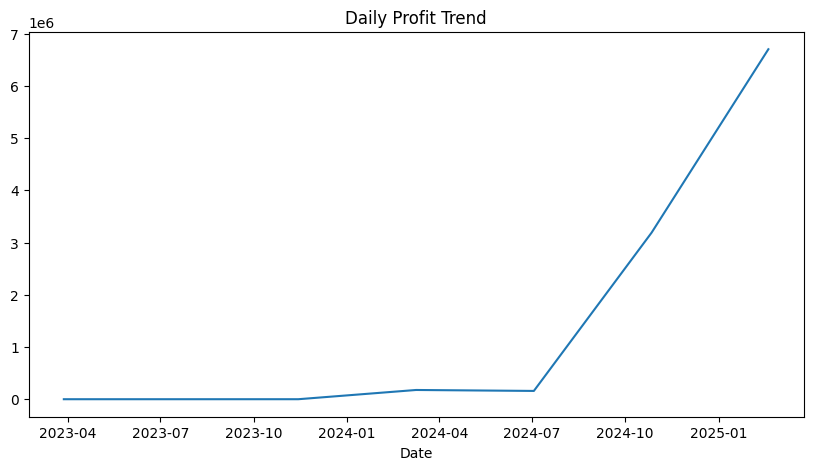

In [18]:
daily_profit = data.groupby("Date")["Closed PnL"].sum()

daily_profit.plot(figsize=(10,5))
plt.title("Daily Profit Trend")
plt.show()

**Explanation**
This line graph shows how total trading profit changes over time.
It helps understand how market conditions affect trader profitability on different days.

**Sentiment Heatmap**

/tmp/ipykernel_913/937982782.py:1: FutureWarning: The provided callable <function mean at 0x79fb417154e0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot = pd.pivot_table(


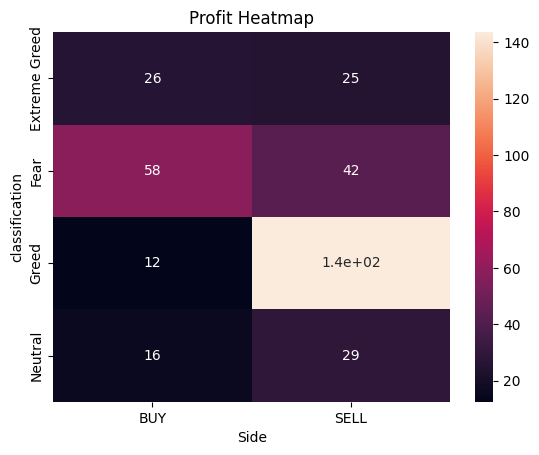

In [19]:
pivot = pd.pivot_table(
data,
values="Closed PnL",
index="classification",
columns="Side",
aggfunc=np.mean
)

sns.heatmap(pivot,annot=True)
plt.title("Profit Heatmap")
plt.show()

**Explanation**
This heatmap shows the average profit for buy and sell trades under different market sentiments.
It helps identify which trading strategy performs better in Fear or Greed markets.

**Interactive Graph**

In [20]:
fig = px.scatter(
data,
x="Size USD",
y="Closed PnL",
color="classification",
title="Trade Size vs Profit"
)

fig.show()

**Explanation**
This interactive graph visualizes trade size, profit, and market sentiment simultaneously.
It helps explore patterns in trader behavior and identify profitable trading clusters.

**Machine Learning Model (XGBoost)**

In [21]:
features = data[[
"Size USD",
"Fee",
"sentiment_label"
]]

target = data["Closed PnL"]

The XGBoost model is used to predict trader profit based on trading features.
It helps identify how factors like trade size, fees, and market sentiment influence profitability.

In [22]:
X_train,X_test,y_train,y_test = train_test_split(
features,
target,
test_size=0.2,
random_state=42
)

In [23]:
model = XGBRegressor(
n_estimators=200,
learning_rate=0.05,
max_depth=6
)

model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

**Prediction**

In [24]:
pred = model.predict(X_test)

print("MAE:",mean_absolute_error(y_test,pred))
print("R2 Score:",r2_score(y_test,pred))

MAE: 103.1975706703152
R2 Score: -0.03572855140320441


**Feature Importance**

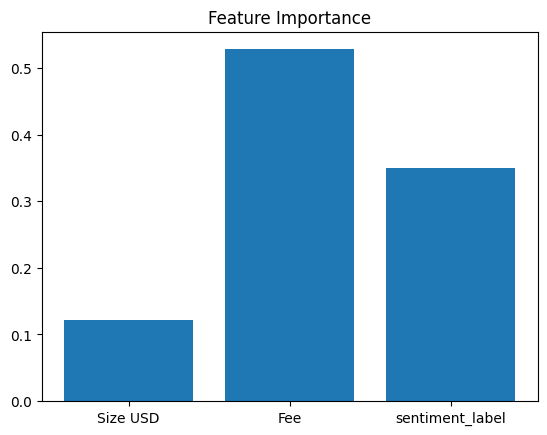

In [25]:
importance = model.feature_importances_

plt.bar(features.columns,importance)
plt.title("Feature Importance")
plt.show()